In [2]:
from datetime import date
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"
output_path =  parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

# Input data

In [39]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
FMP_U2OS_Norm_file_name = '/*[0-9]_' + 'FMP_U2OS_norm.csv'
FMP_U2OS_Norm_path = glob.glob(input_path + FMP_U2OS_Norm_file_name)

### gets latest file
max_FMP_U2OS_Norm = max(FMP_U2OS_Norm_path, key=os.path.getctime)

### load file
FMP_U2OS_Norm = pd.read_csv(max_FMP_U2OS_Norm)
FMP_U2OS_Norm.shape

(10629, 2984)

In [5]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
FMP_HepG2_Norm_file_name = '/*[0-9]_' + 'FMP_HepG2_norm.csv'
FMP_HepG2_Norm_path = glob.glob(input_path + FMP_HepG2_Norm_file_name)

### gets latest file
max_FMP_HepG2_Norm = max(FMP_HepG2_Norm_path, key=os.path.getctime)

### load file
FMP_HepG2_Norm = pd.read_csv(max_FMP_HepG2_Norm)
FMP_HepG2_Norm.shape

(10697, 2984)

In [6]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
IMTM_HepG2_Norm_file_name = '/*[0-9]_' + 'IMTM_HepG2_norm.csv'
IMTM_HepG2_Norm_path = glob.glob(input_path + IMTM_HepG2_Norm_file_name)

### gets latest file
max_IMTM_HepG2_Norm = max(IMTM_HepG2_Norm_path, key=os.path.getctime)

### load file
IMTM_HepG2_Norm = pd.read_csv(max_IMTM_HepG2_Norm)
IMTM_HepG2_Norm.shape

(10668, 2984)

In [7]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
MEDI_HepG2_Norm_file_name = '/*[0-9]_' + 'MEDINA_HepG2_norm.csv'
MEDI_HepG2_Norm_path = glob.glob(input_path + MEDI_HepG2_Norm_file_name)

### gets latest file
max_MEDI_HepG2_Norm = max(MEDI_HepG2_Norm_path, key=os.path.getctime)

### load file
MEDI_HepG2_Norm = pd.read_csv(max_MEDI_HepG2_Norm)
MEDI_HepG2_Norm.shape

(10735, 2984)

In [8]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
USC_HepG2_Norm_file_name = '/*[0-9]_' + 'USC_HepG2_norm.csv'
USC_HepG2_Norm_path = glob.glob(input_path + USC_HepG2_Norm_file_name)

### gets latest file
max_USC_HepG2_Norm = max(USC_HepG2_Norm_path, key=os.path.getctime)

### load file
USC_HepG2_Norm = pd.read_csv(max_USC_HepG2_Norm)
USC_HepG2_Norm.shape

(10747, 2984)

# Process data

In [9]:
FMP_U2OS_Norm_mod = FMP_U2OS_Norm[
    FMP_U2OS_Norm.columns[
        FMP_U2OS_Norm.columns.isin(
            ["Metadata_EOS", 
             "Metadata_Well", 
             "Metadata_Batch", 
             "Metadata_Plate", 
             "Metadata_Object_Count"])]]

In [10]:
FMP_HepG2_Norm_mod = FMP_HepG2_Norm[
    FMP_HepG2_Norm.columns[
        FMP_HepG2_Norm.columns.isin(
            ["Metadata_EOS", 
             "Metadata_Well", 
             "Metadata_Batch", 
             "Metadata_Plate", 
             "Metadata_Object_Count"])]]

In [11]:
IMTM_HepG2_Norm_mod = IMTM_HepG2_Norm[
    IMTM_HepG2_Norm.columns[
        IMTM_HepG2_Norm.columns.isin(
            ["Metadata_EOS", 
             "Metadata_Well", 
             "Metadata_Batch", 
             "Metadata_Plate", 
             "Metadata_Object_Count"])]]

In [12]:
MEDI_HepG2_Norm_mod = MEDI_HepG2_Norm[
    MEDI_HepG2_Norm.columns[
        MEDI_HepG2_Norm.columns.isin(
            ["Metadata_EOS", 
             "Metadata_Well", 
             "Metadata_Batch", 
             "Metadata_Plate", 
             "Metadata_Object_Count"])]]

In [13]:
USC_HepG2_Norm_mod = USC_HepG2_Norm[
    USC_HepG2_Norm.columns[
        USC_HepG2_Norm.columns.isin(
            ["Metadata_EOS", 
             "Metadata_Well", 
             "Metadata_Batch", 
             "Metadata_Plate", 
             "Metadata_Object_Count"])]]

In [14]:
cell_number_FMP_IMTM = pd.merge(FMP_HepG2_Norm_mod,
                       IMTM_HepG2_Norm_mod,
                       suffixes = ["_FMP", "_IMTM"],
                       on = ["Metadata_EOS", 
                             "Metadata_Well", 
                             "Metadata_Batch", 
                             "Metadata_Plate"],
                       how = "outer")

In [15]:
cell_number_FMP_IMTM_MEDI = pd.merge(cell_number_FMP_IMTM,
                       MEDI_HepG2_Norm_mod,
                       on = ["Metadata_EOS", 
                             "Metadata_Well", 
                             "Metadata_Batch", 
                             "Metadata_Plate"],
                       how = "outer")

In [16]:
cell_number_FMP_IMTM_MEDI = cell_number_FMP_IMTM_MEDI.rename(columns={"Metadata_Object_Count": "Metadata_Object_Count_MEDI"})

In [17]:
cell_number_FMP_IMTM_MEDI.head()

,Metadata_EOS,Metadata_Object_Count_FMP,Metadata_Plate,Metadata_Well,Metadata_Batch,Metadata_Object_Count_IMTM,Metadata_Object_Count_MEDI
0,EOS100001,700.0,B1001,A01,R1,401.0,1424.0
1,EOS100002,1004.0,B1001,C01,R1,967.0,1849.0
2,EOS100003,516.0,B1001,E01,R1,470.0,925.0
3,EOS100004,792.0,B1001,G01,R1,1112.0,1947.0
4,EOS100005,857.0,B1001,I01,R1,457.0,2024.0


In [18]:
cell_number_FMP_IMTM_MEDI_USC = pd.merge(cell_number_FMP_IMTM_MEDI,
                       USC_HepG2_Norm_mod,
                       on = ["Metadata_EOS", "Metadata_Well", "Metadata_Batch", "Metadata_Plate"],
                       how = "outer")

In [19]:
cell_number_FMP_IMTM_MEDI_USC = cell_number_FMP_IMTM_MEDI_USC.rename(columns={"Metadata_Object_Count": "Metadata_Object_Count_USC"})

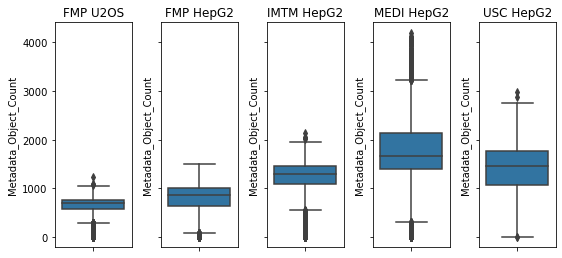

In [20]:
import matplotlib.ticker as ticker

fig, (ax1, ax2, ax3, ax4, ax5)= plt.subplots(1,5, sharex=True, sharey=True)

tick_spacing = 500

ax1.title.set_text('FMP U2OS')
ax2.title.set_text('FMP HepG2')
ax3.title.set_text('IMTM HepG2')
ax4.title.set_text('MEDI HepG2')
ax5.title.set_text('USC HepG2')

fig.tight_layout(pad=1.5)

sns.boxplot(data=FMP_U2OS_Norm, y="Metadata_Object_Count", ax = ax1)
sns.boxplot(data=FMP_HepG2_Norm, y="Metadata_Object_Count", ax = ax2)
sns.boxplot(data=IMTM_HepG2_Norm, y="Metadata_Object_Count", ax = ax3)
sns.boxplot(data=MEDI_HepG2_Norm, y="Metadata_Object_Count", ax = ax4)
sns.boxplot(data=USC_HepG2_Norm, y="Metadata_Object_Count", ax = ax5)

fig.set_figwidth(8)

plt.savefig(figure_path + str(date.today()) + '_CellNumber_all_box.pdf',  dpi=300)

In [21]:
# TODO: Get median cell number and MAD for Table 2
FMP_U2OS_Norm.head()

,Metadata_EOS,Metadata_Object_Count,Metadata_Plate,Metadata_Well,Metadata_Partner,Metadata_Batch,Metadata_Concentration,Nuc_AreaShape_Area,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMaximum_X,...,Cyto_Texture_Variance_Mito_10_02_256,Cyto_Texture_Variance_Mito_10_03_256,Cyto_Texture_Variance_Mito_3_00_256,Cyto_Texture_Variance_Mito_3_01_256,Cyto_Texture_Variance_Mito_3_02_256,Cyto_Texture_Variance_Mito_3_03_256,Cyto_Texture_Variance_Mito_5_00_256,Cyto_Texture_Variance_Mito_5_01_256,Cyto_Texture_Variance_Mito_5_02_256,Cyto_Texture_Variance_Mito_5_03_256
0,EOS100001,101,B1001,A01,Bioactives,R1,10,12.815324,10.884885,0.389706,...,-0.263248,-0.272202,-0.230280,-0.216931,-0.193160,-0.225034,-0.216357,-0.244513,-0.214921,-0.241746
1,EOS100002,556,B1001,C01,Bioactives,R1,10,-0.468396,-0.930332,0.554581,...,0.264812,0.342524,0.300514,0.283276,0.281956,0.308982,0.311203,0.277856,0.269046,0.289728
2,EOS100003,203,B1001,E01,Bioactives,R1,10,16.487552,13.396782,0.839366,...,0.345672,0.399349,0.308788,0.318466,0.344022,0.366141,0.334246,0.337664,0.321438,0.342289
3,EOS100004,660,B1001,G01,Bioactives,R1,10,1.517604,1.767631,-0.689479,...,-0.337480,-0.331639,-0.330276,-0.316996,-0.333259,-0.334496,-0.328768,-0.340194,-0.346482,-0.345826
4,EOS100005,685,B1001,I01,Bioactives,R1,10,-0.974264,-1.186173,-1.468891,...,-0.228635,-0.183095,-0.221620,-0.209057,-0.222743,-0.237187,-0.223536,-0.214737,-0.226701,-0.229876


In [22]:
FMP_median = FMP_U2OS_Norm["Metadata_Object_Count"].median()
FMP_mad = np.median(np.abs(FMP_U2OS_Norm["Metadata_Object_Count"] - FMP_median))

print(f"FMP U2OS Median: {FMP_median}; FMP U2OS MAD: {FMP_mad}")

FMP U2OS Median: 691.0; FMP U2OS MAD: 91.0


In [23]:
FMP_HepG2_median = FMP_HepG2_Norm["Metadata_Object_Count"].median()
FMP_HepG2_mad = np.median(np.abs(FMP_HepG2_Norm["Metadata_Object_Count"] - FMP_HepG2_median))

print(f"FMP HepG2 Median: {FMP_HepG2_median}; FMP HepG2 MAD: {FMP_HepG2_mad}")

FMP HepG2 Median: 863.0; FMP HepG2 MAD: 180.0


In [24]:
IMTM_HepG2_median = IMTM_HepG2_Norm["Metadata_Object_Count"].median()
IMTM_HepG2_mad = np.median(np.abs(IMTM_HepG2_Norm["Metadata_Object_Count"] - IMTM_HepG2_median))

print(f"FMP HepG2 Median: {IMTM_HepG2_median}; FMP HepG2 MAD: {IMTM_HepG2_mad}")

FMP HepG2 Median: 1293.0; FMP HepG2 MAD: 178.0


In [25]:
USC_HepG2_median = USC_HepG2_Norm["Metadata_Object_Count"].median()
USC_HepG2_mad = np.median(np.abs(USC_HepG2_Norm["Metadata_Object_Count"] - USC_HepG2_median))

print(f"FMP HepG2 Median: {USC_HepG2_median}; FMP HepG2 MAD: {USC_HepG2_mad}")

FMP HepG2 Median: 1455.0; FMP HepG2 MAD: 347.0


In [26]:
MEDI_HepG2_median = MEDI_HepG2_Norm["Metadata_Object_Count"].median()
MEDI_HepG2_mad = np.median(np.abs(MEDI_HepG2_Norm["Metadata_Object_Count"] - MEDI_HepG2_median))

print(f"FMP HepG2 Median: {MEDI_HepG2_median}; FMP HepG2 MAD: {MEDI_HepG2_mad}")

FMP HepG2 Median: 1659.0; FMP HepG2 MAD: 347.0


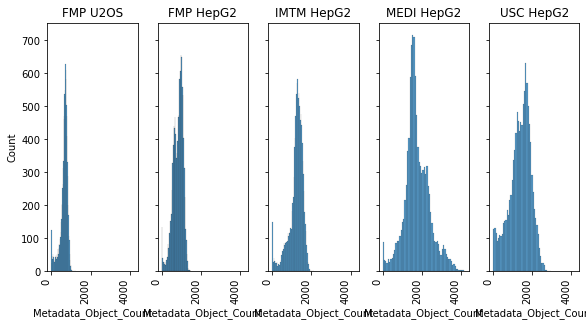

In [27]:
fig, (ax1, ax2, ax3, ax4, ax5)= plt.subplots(1,5, sharex=True, sharey=True)

fig.autofmt_xdate()

ax1.title.set_text('FMP U2OS')
ax1.tick_params(axis='x', labelrotation = 90)

ax2.title.set_text('FMP HepG2')
ax2.tick_params(axis='x', labelrotation = 90)

ax3.title.set_text('IMTM HepG2')
ax3.tick_params(axis='x', labelrotation = 90)

ax4.title.set_text('MEDI HepG2')
ax4.tick_params(axis='x', labelrotation = 90)

ax5.title.set_text('USC HepG2')
ax5.tick_params(axis='x', labelrotation = 90)

fig.tight_layout(pad=0.5)

sns.histplot(data=FMP_U2OS_Norm, x="Metadata_Object_Count", ax = ax1)
sns.histplot(data=FMP_HepG2_Norm, x="Metadata_Object_Count", ax = ax2)
sns.histplot(data=IMTM_HepG2_Norm, x="Metadata_Object_Count", ax = ax3)
sns.histplot(data=MEDI_HepG2_Norm, x="Metadata_Object_Count", ax = ax4)
sns.histplot(data=USC_HepG2_Norm, x="Metadata_Object_Count", ax = ax5)

fig.set_figwidth(8)

plt.savefig(figure_path + str(date.today()) + '_CellNumber_all_histo.pdf',  dpi=300)

In [28]:
# plot cell numbers of controls
FMP_U2OS_Norm_Controls = FMP_U2OS_Norm[(FMP_U2OS_Norm["Metadata_EOS"] == "DMSO") |
                                    (FMP_U2OS_Norm["Metadata_EOS"] == "Nocodazole") |
                                    (FMP_U2OS_Norm["Metadata_EOS"] == "Tetrandrine") ]

In [29]:
# plot cell numbers of controls
FMP_HepG2_Norm_Controls = FMP_HepG2_Norm[(FMP_HepG2_Norm["Metadata_EOS"] == "DMSO") |
                                    (FMP_HepG2_Norm["Metadata_EOS"] == "Nocodazole") |
                                    (FMP_HepG2_Norm["Metadata_EOS"] == "Tetrandrine") ]

In [30]:
# plot cell numbers of controls
IMTM_HepG2_Norm_Controls = IMTM_HepG2_Norm[(IMTM_HepG2_Norm["Metadata_EOS"] == "DMSO") |
                                    (IMTM_HepG2_Norm["Metadata_EOS"] == "Nocodazole") |
                                    (IMTM_HepG2_Norm["Metadata_EOS"] == "Tetrandrine") ]

In [31]:
# plot cell numbers of controls
MEDI_HepG2_Norm_Controls = MEDI_HepG2_Norm[(MEDI_HepG2_Norm["Metadata_EOS"] == "DMSO") |
                                    (MEDI_HepG2_Norm["Metadata_EOS"] == "Nocodazole") |
                                    (MEDI_HepG2_Norm["Metadata_EOS"] == "Tetrandrine") ]

In [32]:
# plot cell numbers of controls
USC_HepG2_Norm_Controls = USC_HepG2_Norm[(USC_HepG2_Norm["Metadata_EOS"] == "DMSO") |
                                    (USC_HepG2_Norm["Metadata_EOS"] == "Nocodazole") |
                                    (USC_HepG2_Norm["Metadata_EOS"] == "Tetrandrine") ]

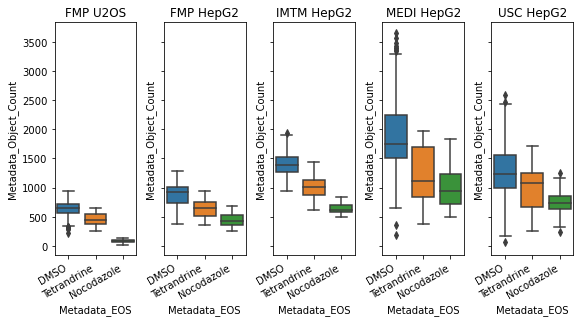

In [33]:
fig, (ax1, ax2, ax3, ax4, ax5)= plt.subplots(1,5, sharex=True, sharey=True)

fig.autofmt_xdate()


ax1.title.set_text('FMP U2OS')
ax2.title.set_text('FMP HepG2')
ax3.title.set_text('IMTM HepG2')
ax4.title.set_text('MEDI HepG2')
ax5.title.set_text('USC HepG2')

fig.tight_layout(pad=1)

plot_order = order=['DMSO', 'Tetrandrine', 'Nocodazole']

sns.boxplot(data=FMP_U2OS_Norm_Controls, y="Metadata_Object_Count", x="Metadata_EOS", ax=ax1, order=plot_order)
sns.boxplot(data=FMP_HepG2_Norm_Controls, y="Metadata_Object_Count", x="Metadata_EOS", ax=ax2, order=plot_order)
sns.boxplot(data=IMTM_HepG2_Norm_Controls, y="Metadata_Object_Count", x="Metadata_EOS", ax=ax3, order=plot_order)
sns.boxplot(data=MEDI_HepG2_Norm_Controls, y="Metadata_Object_Count", x="Metadata_EOS", ax=ax4, order=plot_order)
sns.boxplot(data=USC_HepG2_Norm_Controls, y="Metadata_Object_Count", x="Metadata_EOS", ax=ax5, order=plot_order)

#fig.set_figheight(15)
fig.set_figwidth(8)

plt.savefig(figure_path + str(date.today()) + '_CellNumber_all_controls.pdf',  dpi=300)

# Cell Number Correlations

In [40]:
FMP_U2OS_Norm.head()

,Metadata_EOS,Metadata_Object_Count,Metadata_Plate,Metadata_Well,Metadata_Partner,Metadata_Batch,Metadata_Concentration,Nuc_AreaShape_Area,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMaximum_X,...,Cyto_Texture_Variance_Mito_10_02_256,Cyto_Texture_Variance_Mito_10_03_256,Cyto_Texture_Variance_Mito_3_00_256,Cyto_Texture_Variance_Mito_3_01_256,Cyto_Texture_Variance_Mito_3_02_256,Cyto_Texture_Variance_Mito_3_03_256,Cyto_Texture_Variance_Mito_5_00_256,Cyto_Texture_Variance_Mito_5_01_256,Cyto_Texture_Variance_Mito_5_02_256,Cyto_Texture_Variance_Mito_5_03_256
0,EOS100001,101,B1001,A01,Bioactives,R1,10,12.815324,10.884885,0.389706,...,-0.263248,-0.272202,-0.230280,-0.216931,-0.193160,-0.225034,-0.216357,-0.244513,-0.214921,-0.241746
1,EOS100002,556,B1001,C01,Bioactives,R1,10,-0.468396,-0.930332,0.554581,...,0.264812,0.342524,0.300514,0.283276,0.281956,0.308982,0.311203,0.277856,0.269046,0.289728
2,EOS100003,203,B1001,E01,Bioactives,R1,10,16.487552,13.396782,0.839366,...,0.345672,0.399349,0.308788,0.318466,0.344022,0.366141,0.334246,0.337664,0.321438,0.342289
3,EOS100004,660,B1001,G01,Bioactives,R1,10,1.517604,1.767631,-0.689479,...,-0.337480,-0.331639,-0.330276,-0.316996,-0.333259,-0.334496,-0.328768,-0.340194,-0.346482,-0.345826
4,EOS100005,685,B1001,I01,Bioactives,R1,10,-0.974264,-1.186173,-1.468891,...,-0.228635,-0.183095,-0.221620,-0.209057,-0.222743,-0.237187,-0.223536,-0.214737,-0.226701,-0.229876


In [80]:
columns_to_keep = ['Metadata_EOS', 'Metadata_Object_Count', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Batch']

In [81]:
FMP_U2OS_Norm_cellnumber = FMP_U2OS_Norm[columns_to_keep]
FMP_U2OS_median_cellnumber = FMP_U2OS_Norm_cellnumber.groupby(['Metadata_EOS', 'Metadata_Plate', 'Metadata_Well'])['Metadata_Object_Count'].median()
FMP_U2OS_median_cellnumber = FMP_U2OS_median_cellnumber.reset_index()
FMP_U2OS_median_cellnumber = FMP_U2OS_median_cellnumber.rename(columns={'Metadata_Object_Count': 'FMP_U2OS'})

In [ ]:
FMP_HepG2_Norm_cellnumber = FMP_HepG2_Norm[columns_to_keep]
FMP_HepG2_median_cellnumber = FMP_HepG2_Norm_cellnumber.groupby(['Metadata_EOS', 'Metadata_Plate', 'Metadata_Well'])['Metadata_Object_Count'].median()
FMP_HepG2_median_cellnumber = FMP_HepG2_median_cellnumber.reset_index()
FMP_HepG2_median_cellnumber = FMP_HepG2_median_cellnumber.rename(columns={'Metadata_Object_Count': 'FMP_HepG2'})

In [83]:
IMTM_HepG2_Norm_cellnumber = IMTM_HepG2_Norm[columns_to_keep]
IMTM_HepG2_median_cellnumber = IMTM_HepG2_Norm_cellnumber.groupby(['Metadata_EOS', 'Metadata_Plate', 'Metadata_Well'])['Metadata_Object_Count'].median()
IMTM_HepG2_median_cellnumber = IMTM_HepG2_median_cellnumber.reset_index()
IMTM_HepG2_median_cellnumber = IMTM_HepG2_median_cellnumber.rename(columns={'Metadata_Object_Count': 'IMTM_HepG2'})

In [84]:
MEDINA_HepG2_Norm_cellnumber = MEDI_HepG2_Norm[columns_to_keep]
MEDINA_HepG2_median_cellnumber = MEDINA_HepG2_Norm_cellnumber.groupby(['Metadata_EOS', 'Metadata_Plate', 'Metadata_Well'])['Metadata_Object_Count'].median()
MEDINA_HepG2_median_cellnumber = MEDINA_HepG2_median_cellnumber.reset_index()
MEDINA_HepG2_median_cellnumber = MEDINA_HepG2_median_cellnumber.rename(columns={'Metadata_Object_Count': 'MEDINA_HepG2'})

In [85]:
USC_HepG2_Norm_cellnumber = USC_HepG2_Norm[columns_to_keep]
USC_HepG2_median_cellnumber = USC_HepG2_Norm_cellnumber.groupby(['Metadata_EOS', 'Metadata_Plate', 'Metadata_Well'])['Metadata_Object_Count'].median()
USC_HepG2_median_cellnumber = USC_HepG2_median_cellnumber.reset_index()
USC_HepG2_median_cellnumber = USC_HepG2_median_cellnumber.rename(columns={'Metadata_Object_Count': 'USC_HepG2'})

In [86]:
df_merged = pd.merge(FMP_U2OS_median_cellnumber, FMP_HepG2_median_cellnumber, on=['Metadata_EOS','Metadata_Plate', 'Metadata_Well'], how='inner') 
df_merged = pd.merge(df_merged, IMTM_HepG2_median_cellnumber , on=['Metadata_EOS','Metadata_Plate', 'Metadata_Well'], how='inner')
df_merged = pd.merge(df_merged, MEDINA_HepG2_median_cellnumber, on=['Metadata_EOS','Metadata_Plate', 'Metadata_Well'], how='inner')
df_merged = pd.merge(df_merged, USC_HepG2_median_cellnumber , on=['Metadata_EOS','Metadata_Plate', 'Metadata_Well'], how='inner')

In [100]:
# Select the numerical columns
numerical_columns = ['FMP_U2OS', 'FMP_HepG2', 'IMTM_HepG2', 'MEDINA_HepG2', 'USC_HepG2']

# Calculate the correlation matrix for numerical columns
corr_matrix = df_merged[numerical_columns].corr()


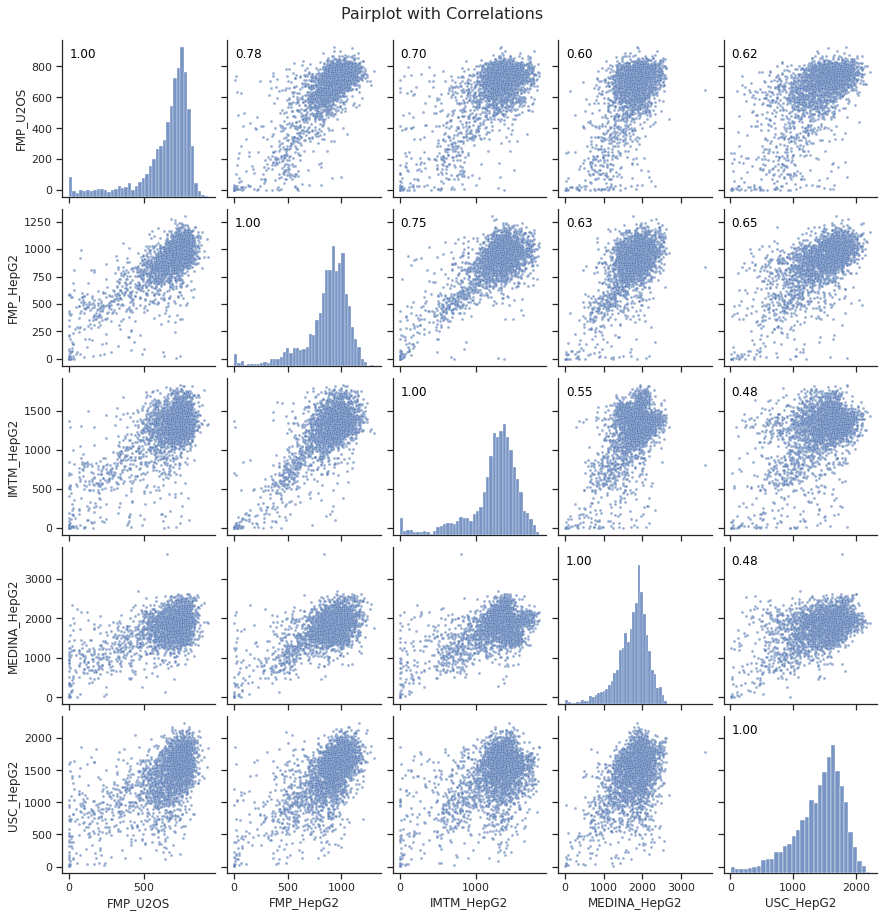

In [103]:
# Create the pairplot
g = sns.pairplot(df_merged, vars=numerical_columns, kind='scatter', plot_kws={'s': 8, 'alpha': 0.6})

# Loop over the diagonal axes to add correlation values
for i, j in zip(*np.triu_indices_from(corr_matrix, k=0)):
    ax = g.axes[i, j]  # Access each subplot
    corr_value = corr_matrix.iloc[i, j]  # Get the correlation value for this pair
    ax.annotate(f'{corr_value:.2f}', 
                xy=(0.05, 0.95), 
                xycoords='axes fraction', 
                ha='left', 
                va='top', 
                fontsize=12, 
                color='black')

# Set overall title or additional labels
plt.suptitle('Pairplot with Correlations', 
             size=16, 
             y=1.02)

# Save the plot (optional)
plt.savefig(figure_path + str(date.today()) + '_CellNumber_2DPlot_Correlation',  dpi=300)

# Show the plot
plt.show()
